<mark><font color=red size=4 face=雅黑>叠加字体的变化<font><mark>

<mark>黄色高亮<mark>

<font color=steel size=5 face=雅黑>5号雅黑</font>

**<font color=green>绿色+加粗+斜体</font>**

## 一、读取数据&创建字典结构

In [1]:
import pandas as pd
import numpy as np
import os
from datetime import datetime

# 读取Excel文件中的收盘价和成交量数据
def load_stock_data(file_path):
    """
    读取Excel文件中的收盘价和成交量数据，创建字典结构
    
    参数:
    file_path: Excel文件路径
    
    返回:
    dict: 包含收盘价和成交量数据的字典

    种数据结构既保留了原始DataFrame便于按日期查询，又创建了按股票代码组织的字典便于单只股票的历史数据分析。您可以:
    通过 data['stock_data']['000001.SZ'] 获取单只股票的所有数据
    通过 data['close_df'].loc['2023-01-05'] 获取特定日期所有股票的收盘价
    通过上面提供的辅助函数快速获取所需数据
    后续识别旗形形态时，可以遍历每只股票的历史数据进行分析。

    """
    print(f"正在读取 {file_path} 文件...")
    
    # 读取收盘价sheet
    close_df = pd.read_excel(file_path, sheet_name='收盘价', index_col=0)
    # 读取成交量sheet
    volume_df = pd.read_excel(file_path, sheet_name='成交量', index_col=0)
    
    print(f"数据读取完成，收盘价数据形状: {close_df.shape}, 成交量数据形状: {volume_df.shape}")
    
    # 获取所有股票代码
    stock_codes = close_df.columns.tolist()
    
    # 创建字典结构
    stock_data = {}
    
    # 计算对数收盘价
    ln_close_df = np.log(close_df)
    
    for code in stock_codes:
        # 提取当前股票的收盘价和成交量数据
        close_series = close_df[code].dropna()
        volume_series = volume_df[code].dropna()
        ln_close_series = ln_close_df[code].dropna()
        
        # 确保三个序列有相同的索引
        common_dates = close_series.index.intersection(volume_series.index).intersection(ln_close_series.index)
        
        # 创建当前股票的数据字典
        stock_data[code] = {
            'dates': common_dates,
            'close': close_series[common_dates].values,
            'volume': volume_series[common_dates].values,
            'ln_close': ln_close_series[common_dates].values
        }
    
    print(f"成功创建 {len(stock_data)} 只股票的数据字典")
    
    return {
        'stock_data': stock_data,          # 股票数据字典
        'close_df': close_df,              # 原始收盘价DataFrame
        'ln_close_df': ln_close_df,        # 对数收盘价DataFrame
        'volume_df': volume_df,            # 原始成交量DataFrame
        'dates': close_df.index.tolist(),  # 所有日期列表
        'stocks': stock_codes              # 所有股票代码列表
    }

# 示例用法
file_path = '全部A股数据.xlsx'
data_raw = load_stock_data(file_path)

# 输出数据结构示例
print("\n数据结构示例:")
print("可用的键:", list(data_raw.keys()))
print("总股票数量:", len(data_raw['stocks']))
print("总交易日数量:", len(data_raw['dates']))

# 查看第一只股票的数据
first_stock = data_raw['stocks'][0]
print(f"\n第一只股票 {first_stock} 的数据结构:")
print(f"数据日期数量: {len(data_raw['stock_data'][first_stock]['dates'])}")
print(f"收盘价前5个值: {data_raw['stock_data'][first_stock]['close'][:5]}")
print(f"成交量前5个值: {data_raw['stock_data'][first_stock]['volume'][:5]}")

# 直接获取特定日期的所有股票收盘价
def get_close_prices(data_raw, date):
    """获取特定日期的所有股票收盘价"""
    if date in data_raw['close_df'].index:
        return data_raw['close_df'].loc[date].to_dict()
    return {}

# 直接获取特定日期的所有股票ln收盘价
def get_close_prices(data_raw, date):
    """获取特定日期的所有股票ln收盘价"""
    if date in data_raw['ln_close_df'].index:
        return data_raw['ln_close_df'].loc[date].to_dict()
    return {}

# 获取特定股票的所有历史数据
def get_stock_history(data_raw, stock_code):
    """获取特定股票的所有历史数据"""
    if stock_code in data_raw['stock_data']:
        stock_info = data_raw['stock_data'][stock_code]
        df = pd.DataFrame({
            'close': stock_info['close'],
            'ln_close': stock_info['ln_close'],
            'volume': stock_info['volume']
        }, index=stock_info['dates'])
        return df
    return None

# 示例: 获取第一只股票的历史数据.sort_index(ascending=False)
first_stock_history = get_stock_history(data_raw, first_stock)
first_stock_history


正在读取 全部A股数据.xlsx 文件...
数据读取完成，收盘价数据形状: (1755, 3644), 成交量数据形状: (1755, 3644)
成功创建 3644 只股票的数据字典

数据结构示例:
可用的键: ['stock_data', 'close_df', 'ln_close_df', 'volume_df', 'dates', 'stocks']
总股票数量: 3644
总交易日数量: 1755

第一只股票 000004.SZ 的数据结构:
数据日期数量: 1755
收盘价前5个值: [22.34 23.8  23.24 23.18 22.84]
成交量前5个值: [ 626181. 1879539. 1454066. 1044404.  717585.]


,close,ln_close,volume
2018-01-02,22.34,3.106379,626181.0
2018-01-03,23.80,3.169686,1879539.0
2018-01-04,23.24,3.145875,1454066.0
2018-01-05,23.18,3.143290,1044404.0
2018-01-08,22.84,3.128513,717585.0
...,...,...,...
2025-03-24,10.50,2.351375,15188900.0
2025-03-25,10.25,2.327278,9250500.0
2025-03-26,10.36,2.337952,4815700.0
2025-03-27,10.17,2.319442,4839000.0


In [2]:
data_raw

{'stock_data': {'000004.SZ': {'dates': DatetimeIndex(['2018-01-02', '2018-01-03', '2018-01-04', '2018-01-05',
                  '2018-01-08', '2018-01-09', '2018-01-10', '2018-01-11',
                  '2018-01-12', '2018-01-15',
                  ...
                  '2025-03-17', '2025-03-18', '2025-03-19', '2025-03-20',
                  '2025-03-21', '2025-03-24', '2025-03-25', '2025-03-26',
                  '2025-03-27', '2025-03-28'],
                 dtype='datetime64[ns]', length=1755, freq=None),
   'close': array([22.34, 23.8 , 23.24, ..., 10.36, 10.17, 10.  ]),
   'volume': array([ 626181., 1879539., 1454066., ..., 4815700., 4839000., 4398800.]),
   'ln_close': array([3.10637879, 3.16968558, 3.14587493, ..., 2.33795224, 2.31944221,
          2.30258509])},
  '600601.SH': {'dates': DatetimeIndex(['2018-01-02', '2018-01-03', '2018-01-04', '2018-01-05',
                  '2018-01-08', '2018-01-09', '2018-01-10', '2018-01-11',
                  '2018-01-12', '2018-01-15',
    

In [31]:
# 展示data数据结构
# data是一个字典，包含以下主要组件：
# 1. 'stock_data': 包含所有股票的详细数据，每只股票包含dates(日期)、close(收盘价)和volume(成交量)
# 2. 'close_df': 所有股票的收盘价DataFrame，行索引为日期，列为股票代码
# 3. 'volume_df': 所有股票的成交量DataFrame，行索引为日期，列为股票代码
# 4. 'dates': 所有交易日期的列表
# 5. 'stocks': 所有股票代码的列表
data = data_raw.copy()
data
# 数据结构说明与使用示例

# 1. 获取所有股票代码列表
stocks_list = data['stocks']
print(f"1. 数据集中共有 {len(stocks_list)} 只股票")
print(f"前5只股票: {stocks_list[:5]}")

# 2. 获取所有交易日期
trading_dates = data['dates']
print(f"2. 数据集中共有 {len(trading_dates)} 个交易日")
print(f"第一个交易日: {trading_dates[0]}")
print(f"最后一个交易日: {trading_dates[-1]}")

# 3. 获取特定股票的历史数据
stock_code = stocks_list[0]  # 以第一只股票为例
stock_history = data['stock_data'][stock_code]
print(f"\n3. 股票 {stock_code} 的数据结构:")
for key in stock_history:
    print(f"- {key}: {type(stock_history[key])}, 长度: {len(stock_history[key])}")

# 4. 将特定股票数据转换为DataFrame
stock_df = pd.DataFrame({
    'close': stock_history['close'],
    'ln_close': stock_history['ln_close'],
    'volume': stock_history['volume']
}, index=stock_history['dates'])
print(f"\n4. 股票 {stock_code} 的前5行数据:")
print(stock_df.head())

# 5. 使用close_df获取特定日期所有股票的收盘价
specific_date = trading_dates[0]  # 以第一个交易日为例
all_stocks_close_on_date = data['close_df'].loc[specific_date]
print(f"\n5.{specific_date} 日所有股票的收盘价前5个:")
print(all_stocks_close_on_date.head())

# 6. 获取特定股票在所有日期的收盘价
specific_stock = stocks_list[0]  # 以第一只股票为例
stock_close_all_dates = data['close_df'][specific_stock]
print(f"\n6.股票 {specific_stock} 的收盘价前5个交易日:")
print(stock_close_all_dates.head())

# 7. 获取特定日期范围内的数据
start_date = trading_dates[0]
end_date = trading_dates[20]  # 前20个交易日
date_range_data = data['close_df'].loc[start_date:end_date, stocks_list[:5]]
print(f"\n7.从 {start_date} 到 {end_date} 的前5只股票收盘价:")
print(date_range_data)

# 8. 使用volume_df获取成交量数据
recent_volume = data['volume_df'].iloc[-5:]  # 最近5个交易日的成交量
print("\n8.最近5个交易日的成交量数据(前3只股票):")
print(recent_volume[stocks_list[:3]])

# 9. 计算特定股票的收益率
stock_code = stocks_list[0]
stock_returns = data['close_df'][stock_code].pct_change().dropna()
print(f"\n9.股票 {stock_code} 的日收益率前5个交易日:")
print(stock_returns.head())

# 10. 筛选满足特定条件的股票
# 例如：找出最近一个交易日收盘价大于20的股票
last_date = trading_dates[-1]
high_price_stocks = data['close_df'].loc[last_date][data['close_df'].loc[last_date] > 20]
print(f"\n10.最近交易日({last_date})收盘价大于20的股票数量: {len(high_price_stocks)}")
if len(high_price_stocks) > 0:
    print(f"前5只: {high_price_stocks.head()}")


1. 数据集中共有 3644 只股票
前5只股票: ['000004.SZ', '600601.SH', '600602.SH', '600651.SH', '600653.SH']
2. 数据集中共有 1755 个交易日
第一个交易日: 2018-01-02 00:00:00
最后一个交易日: 2025-03-28 00:00:00

3. 股票 000004.SZ 的数据结构:
- dates: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>, 长度: 1755
- close: <class 'numpy.ndarray'>, 长度: 1755
- volume: <class 'numpy.ndarray'>, 长度: 1755
- ln_close: <class 'numpy.ndarray'>, 长度: 1755

4. 股票 000004.SZ 的前5行数据:
            close  ln_close     volume
2018-01-02  22.34  3.106379   626181.0
2018-01-03  23.80  3.169686  1879539.0
2018-01-04  23.24  3.145875  1454066.0
2018-01-05  23.18  3.143290  1044404.0
2018-01-08  22.84  3.128513   717585.0

5.2018-01-02 00:00:00 日所有股票的收盘价前5个:
000004.SZ    22.340000
600601.SH     3.288756
600602.SH     6.822257
600651.SH     9.440701
600653.SH     2.710000
Name: 2018-01-02 00:00:00, dtype: float64

6.股票 000004.SZ 的收盘价前5个交易日:
2018-01-02    22.34
2018-01-03    23.80
2018-01-04    23.24
2018-01-05    23.18
2018-01-08    22.84
Name: 000004.SZ, dty

In [17]:
# 获取列表中的第三个元素（索引为2）
stocks_list[1]



'600601.SH'

In [28]:
dat111_slice = stock_df['ln_close'] 

dat111_slice

2018-01-02    0.996949
2018-01-03    1.004302
2018-01-04    1.011601
2018-01-05    1.026042
2018-01-08    1.015231
                ...   
2025-03-24    0.737164
2025-03-25    0.732368
2025-03-26    0.751416
2025-03-27    0.737164
2025-03-28    0.722706
Name: ln_close, Length: 1755, dtype: float64

**<font  size=5 face=雅黑>识别旗形&统计计算结果</font>**

In [36]:
from flag_pattern_algorithm_0328 import find_flags_pennants_pips, find_flags_pennants_trendline

# 定义要测试的窗口大小参数范围（从5到50）
orders = list(range(5, 51))

# 创建一个字典来存储所有股票的结果
all_stocks_results = {}

# 创建汇总结果的数据框
summary_results_df = pd.DataFrame(index=orders)

# 初始化汇总数据存储列表
all_bull_flag_count = [0] * len(orders)
all_bull_pennant_count = [0] * len(orders)
all_bear_flag_count = [0] * len(orders)
all_bear_pennant_count = [0] * len(orders)

all_bull_flag_total_ret = [0] * len(orders)
all_bull_pennant_total_ret = [0] * len(orders)
all_bear_flag_total_ret = [0] * len(orders)
all_bear_pennant_total_ret = [0] * len(orders)

all_bull_flag_wins = [0] * len(orders)
all_bull_pennant_wins = [0] * len(orders)
all_bear_flag_wins = [0] * len(orders)
all_bear_pennant_wins = [0] * len(orders)

# 遍历每只股票
# for stock_code in stocks_list[:2]: 这是获取0、1两只股票
for stock_code in stocks_list:


    print(f"处理股票: {stock_code}")
    
    # 获取特定股票数据
    stock_df = pd.DataFrame({
        'ln_close': np.log(data['close_df'][stock_code]),
        'volume': data['volume_df'][stock_code]
    }, index=data['close_df'].index)
    

    # 使用Series保留原始时间索引信息，而不是使用values属性转换为numpy数组
    dat_slice = stock_df['ln_close']  # dat_slice保留了原始的DatetimeIndex时间索引


    # 初始化结果存储列表
    # 胜率（Win Rate）列表
    bull_flag_wr = []  # 牛市旗形胜率
    bull_pennant_wr = []  # 牛市三角旗胜率
    bear_flag_wr = []  # 熊市旗形胜率
    bear_pennant_wr = []  # 熊市三角旗胜率

    # 平均收益列表
    bull_flag_avg = []  # 牛市旗形平均收益
    bull_pennant_avg = []  # 牛市三角旗平均收益
    bear_flag_avg = []  # 熊市旗形平均收益
    bear_pennant_avg = []  # 熊市三角旗平均收益

    # 形态数量列表
    bull_flag_count = []  # 牛市旗形数量
    bull_pennant_count = []  # 牛市三角旗数量
    bear_flag_count = []  # 熊市旗形数量
    bear_pennant_count = []  # 熊市三角旗数量

    # 总收益列表
    bull_flag_total_ret = []  # 牛市旗形总收益
    bull_pennant_total_ret = []  # 牛市三角旗总收益
    bear_flag_total_ret = []  # 熊市旗形总收益
    bear_pennant_total_ret = []  # 熊市三角旗总收益

    # 创建一个字典来存储每个order参数下的形态详细信息
    pattern_details = {}

    # 遍历每个窗口大小参数进行测试
    for i, order in enumerate(orders):
        # 使用PIP点方法识别旗形和三角旗
        bull_flags, bear_flags, bull_pennants, bear_pennants = find_flags_pennants_pips(dat_slice, order)
        # 也可以使用趋势线方法（取消下面的注释即可）
        # bull_flags, bear_flags, bull_pennants, bear_pennants = find_flags_pennants_trendline(dat_slice, order)

        # 创建数据框来存储形态属性和收益
        bull_flag_df = pd.DataFrame()  # 牛市旗形数据框
        bull_pennant_df = pd.DataFrame()  # 牛市三角旗数据框
        bear_flag_df = pd.DataFrame()  # 熊市旗形数据框
        bear_pennant_df = pd.DataFrame()  # 熊市三角旗数据框

        # 设置持有期乘数（持有时间 = 旗帜宽度 * 乘数）
        hold_mult = 1.0  # 默认持有时间等于旗帜宽度
        
        # 处理牛市旗形数据
        for j, flag in enumerate(bull_flags):
            # 记录形态属性
            bull_flag_df.loc[j, 'flag_width'] = flag.flag_width  # 旗帜宽度
            bull_flag_df.loc[j, 'flag_height'] = flag.flag_height  # 旗帜高度
            bull_flag_df.loc[j, 'pole_width'] = flag.pole_width  # 旗杆宽度
            bull_flag_df.loc[j, 'pole_height'] = flag.pole_height  # 旗杆高度
            bull_flag_df.loc[j, 'slope'] = flag.resist_slope  # 阻力线斜率
            
            # 记录关键点位索引
            bull_flag_df.loc[j, 'start_x'] = flag.base_x  # 起始点索引
            bull_flag_df.loc[j, 'end_x'] = flag.tip_x  # 旗杆顶部索引
            bull_flag_df.loc[j, 'conf_x'] = flag.conf_x  # 确认点索引
            
            # 记录日期信息
            bull_flag_df.loc[j, 'start_date'] = stock_df.index[flag.base_x]  # 起始日期
            bull_flag_df.loc[j, 'end_date'] = stock_df.index[flag.tip_x]  # 旗杆顶部日期
            bull_flag_df.loc[j, 'conf_date'] = stock_df.index[flag.conf_x]  # 确认日期

            # 计算持有期收益
            hp = int(flag.flag_width * hold_mult)  # 持有期长度
            if flag.conf_x + hp >= len(dat_slice):  # 如果持有期超出数据范围
                bull_flag_df.loc[j, 'return'] = np.nan  # 设置收益为NaN
                bull_flag_df.loc[j, 'exit_date'] = np.nan  # 退出日期为NaN
            else:
                # 计算对数收益率（确认点到持有期结束的价格变化）
                ret = dat_slice[flag.conf_x + hp] - dat_slice[flag.conf_x]
                bull_flag_df.loc[j, 'return'] = ret 
                bull_flag_df.loc[j, 'exit_date'] = stock_df.index[flag.conf_x + hp]  # 退出日期

        # 处理熊市旗形数据
        for j, flag in enumerate(bear_flags):
            # 记录形态属性
            bear_flag_df.loc[j, 'flag_width'] = flag.flag_width  # 旗帜宽度
            bear_flag_df.loc[j, 'flag_height'] = flag.flag_height  # 旗帜高度
            bear_flag_df.loc[j, 'pole_width'] = flag.pole_width  # 旗杆宽度
            bear_flag_df.loc[j, 'pole_height'] = flag.pole_height  # 旗杆高度
            bear_flag_df.loc[j, 'slope'] = flag.support_slope  # 支撑线斜率
            
            # 记录关键点位索引
            bear_flag_df.loc[j, 'start_x'] = flag.base_x  # 起始点索引
            bear_flag_df.loc[j, 'end_x'] = flag.tip_x  # 结束点索引
            bear_flag_df.loc[j, 'conf_x'] = flag.conf_x  # 确认点索引
            
            # 记录日期信息
            bear_flag_df.loc[j, 'start_date'] = stock_df.index[flag.base_x]  # 起始日期
            bear_flag_df.loc[j, 'end_date'] = stock_df.index[flag.tip_x]  # 旗杆顶部日期
            bear_flag_df.loc[j, 'conf_date'] = stock_df.index[flag.conf_x]  # 确认日期

            # 计算持有期收益（注意熊市形态是做空，所以收益取负）
            hp = int(flag.flag_width * hold_mult)  # 持有期长度
            if flag.conf_x + hp >= len(dat_slice):  # 如果持有期超出数据范围
                bear_flag_df.loc[j, 'return'] = np.nan  # 设置收益为NaN
                bear_flag_df.loc[j, 'exit_date'] = np.nan  # 退出日期为NaN
            else:
                # 计算对数收益率（确认点到持有期结束的价格变化的负值）
                ret = -1 * (dat_slice[flag.conf_x + hp] - dat_slice[flag.conf_x])
                bear_flag_df.loc[j, 'return'] = ret 
                bear_flag_df.loc[j, 'exit_date'] = stock_df.index[flag.conf_x + hp]  # 退出日期

        # 处理牛市三角旗数据
        for j, pennant in enumerate(bull_pennants):
            # 记录形态属性
            bull_pennant_df.loc[j, 'pennant_width'] = pennant.flag_width  # 三角旗宽度
            bull_pennant_df.loc[j, 'pennant_height'] = pennant.flag_height  # 三角旗高度
            bull_pennant_df.loc[j, 'pole_width'] = pennant.pole_width  # 旗杆宽度
            bull_pennant_df.loc[j, 'pole_height'] = pennant.pole_height  # 旗杆高度
            
            # 记录关键点位索引
            bull_pennant_df.loc[j, 'start_x'] = pennant.base_x  # 起始点索引
            bull_pennant_df.loc[j, 'end_x'] = pennant.tip_x  # 结束点索引
            bull_pennant_df.loc[j, 'conf_x'] = pennant.conf_x  # 确认点索引
            
            # 记录日期信息
            bull_pennant_df.loc[j, 'start_date'] = stock_df.index[pennant.base_x]  # 起始日期
            bull_pennant_df.loc[j, 'end_date'] = stock_df.index[pennant.tip_x]  # 旗杆顶部日期
            bull_pennant_df.loc[j, 'conf_date'] = stock_df.index[pennant.conf_x]  # 确认日期

            # 计算持有期收益
            hp = int(pennant.flag_width * hold_mult)  # 持有期长度
            if pennant.conf_x + hp >= len(dat_slice):  # 如果持有期超出数据范围
                bull_pennant_df.loc[j, 'return'] = np.nan  # 设置收益为NaN
                bull_pennant_df.loc[j, 'exit_date'] = np.nan  # 退出日期为NaN
            else:
                # 计算对数收益率（确认点到持有期结束的价格变化）
                ret = dat_slice[pennant.conf_x + hp] - dat_slice[pennant.conf_x]
                bull_pennant_df.loc[j, 'return'] = ret 
                bull_pennant_df.loc[j, 'exit_date'] = stock_df.index[pennant.conf_x + hp]  # 退出日期

        # 处理熊市三角旗数据
        for j, pennant in enumerate(bear_pennants):
            # 记录形态属性
            bear_pennant_df.loc[j, 'pennant_width'] = pennant.flag_width  # 三角旗宽度
            bear_pennant_df.loc[j, 'pennant_height'] = pennant.flag_height  # 三角旗高度
            bear_pennant_df.loc[j, 'pole_width'] = pennant.pole_width  # 旗杆宽度
            bear_pennant_df.loc[j, 'pole_height'] = pennant.pole_height  # 旗杆高度
            
            # 记录关键点位索引
            bear_pennant_df.loc[j, 'start_x'] = pennant.base_x  # 起始点索引
            bear_pennant_df.loc[j, 'end_x'] = pennant.tip_x  # 结束点索引
            bear_pennant_df.loc[j, 'conf_x'] = pennant.conf_x  # 确认点索引
            
            # 记录日期信息
            bear_pennant_df.loc[j, 'start_date'] = stock_df.index[pennant.base_x]  # 起始日期
            bear_pennant_df.loc[j, 'end_date'] = stock_df.index[pennant.tip_x]  # 旗杆顶部日期
            bear_pennant_df.loc[j, 'conf_date'] = stock_df.index[pennant.conf_x]  # 确认日期

            # 计算持有期收益（注意熊市形态是做空，所以收益取负）
            hp = int(pennant.flag_width * hold_mult)  # 持有期长度
            if pennant.conf_x + hp >= len(dat_slice):  # 如果持有期超出数据范围
                bear_pennant_df.loc[j, 'return'] = np.nan  # 设置收益为NaN
                bear_pennant_df.loc[j, 'exit_date'] = np.nan  # 退出日期为NaN
            else:
                # 计算对数收益率（确认点到持有期结束的价格变化的负值）
                ret = -1 * (dat_slice[pennant.conf_x + hp] - dat_slice[pennant.conf_x])
                bear_pennant_df.loc[j, 'return'] = ret 
                bear_pennant_df.loc[j, 'exit_date'] = stock_df.index[pennant.conf_x + hp]  # 退出日期

        # 保存每个order参数下的形态详细信息
        pattern_details[order] = {
            'bull_flag': bull_flag_df.copy() if not bull_flag_df.empty else None,
            'bear_flag': bear_flag_df.copy() if not bear_flag_df.empty else None,
            'bull_pennant': bull_pennant_df.copy() if not bull_pennant_df.empty else None,
            'bear_pennant': bear_pennant_df.copy() if not bear_pennant_df.empty else None
        }

        # 计算牛市旗形的统计数据
        if not bull_flag_df.empty:
            bull_flag_count.append(len(bull_flag_df))
            valid_returns = bull_flag_df['return'].dropna()
            if not valid_returns.empty:
                bull_flag_avg.append(valid_returns.mean())
                bull_flag_wr.append(len(valid_returns[valid_returns > 0]) / len(valid_returns))
                bull_flag_total_ret.append(valid_returns.sum())
                
                # 更新全局统计
                all_bull_flag_count[i] += len(bull_flag_df)
                all_bull_flag_total_ret[i] += valid_returns.sum()
                all_bull_flag_wins[i] += len(valid_returns[valid_returns > 0])
            else:
                bull_flag_avg.append(np.nan)
                bull_flag_wr.append(np.nan)
                bull_flag_total_ret.append(0)
        else:
            bull_flag_count.append(0)
            bull_flag_avg.append(np.nan)
            bull_flag_wr.append(np.nan)
            bull_flag_total_ret.append(0)
        
        # 计算熊市旗形的统计数据
        if not bear_flag_df.empty:
            bear_flag_count.append(len(bear_flag_df))
            valid_returns = bear_flag_df['return'].dropna()
            if not valid_returns.empty:
                bear_flag_avg.append(valid_returns.mean())
                bear_flag_wr.append(len(valid_returns[valid_returns > 0]) / len(valid_returns))
                bear_flag_total_ret.append(valid_returns.sum())
                
                # 更新全局统计
                all_bear_flag_count[i] += len(bear_flag_df)
                all_bear_flag_total_ret[i] += valid_returns.sum()
                all_bear_flag_wins[i] += len(valid_returns[valid_returns > 0])
            else:
                bear_flag_avg.append(np.nan)
                bear_flag_wr.append(np.nan)
                bear_flag_total_ret.append(0)
        else:
            bear_flag_count.append(0)
            bear_flag_avg.append(np.nan)
            bear_flag_wr.append(np.nan)
            bear_flag_total_ret.append(0)
        
        # 计算牛市三角旗的统计数据
        if not bull_pennant_df.empty:
            bull_pennant_count.append(len(bull_pennant_df))
            valid_returns = bull_pennant_df['return'].dropna()
            if not valid_returns.empty:
                bull_pennant_avg.append(valid_returns.mean())
                bull_pennant_wr.append(len(valid_returns[valid_returns > 0]) / len(valid_returns))
                bull_pennant_total_ret.append(valid_returns.sum())
                
                # 更新全局统计
                all_bull_pennant_count[i] += len(bull_pennant_df)
                all_bull_pennant_total_ret[i] += valid_returns.sum()
                all_bull_pennant_wins[i] += len(valid_returns[valid_returns > 0])
            else:
                bull_pennant_avg.append(np.nan)
                bull_pennant_wr.append(np.nan)
                bull_pennant_total_ret.append(0)
        else:
            bull_pennant_count.append(0)
            bull_pennant_avg.append(np.nan)
            bull_pennant_wr.append(np.nan)
            bull_pennant_total_ret.append(0)
        
        # 计算熊市三角旗的统计数据
        if not bear_pennant_df.empty:
            bear_pennant_count.append(len(bear_pennant_df))
            valid_returns = bear_pennant_df['return'].dropna()
            if not valid_returns.empty:
                bear_pennant_avg.append(valid_returns.mean())
                bear_pennant_wr.append(len(valid_returns[valid_returns > 0]) / len(valid_returns))
                bear_pennant_total_ret.append(valid_returns.sum())
                
                # 更新全局统计
                all_bear_pennant_count[i] += len(bear_pennant_df)
                all_bear_pennant_total_ret[i] += valid_returns.sum()
                all_bear_pennant_wins[i] += len(valid_returns[valid_returns > 0])
            else:
                bear_pennant_avg.append(np.nan)
                bear_pennant_wr.append(np.nan)
                bear_pennant_total_ret.append(0)
        else:
            bear_pennant_count.append(0)
            bear_pennant_avg.append(np.nan)
            bear_pennant_wr.append(np.nan)
            bear_pennant_total_ret.append(0)
    
    # 创建结果数据框，以窗口大小参数为索引
    results_df = pd.DataFrame(index=orders)

    # 添加牛市旗形的统计数据
    results_df['bull_flag_count'] = bull_flag_count  # 形态数量
    results_df['bull_flag_avg'] = bull_flag_avg  # 平均收益
    results_df['bull_flag_wr'] = bull_flag_wr  # 胜率
    results_df['bull_flag_total'] = bull_flag_total_ret  # 总收益

    # 添加熊市旗形的统计数据
    results_df['bear_flag_count'] = bear_flag_count  # 形态数量
    results_df['bear_flag_avg'] = bear_flag_avg  # 平均收益
    results_df['bear_flag_wr'] = bear_flag_wr  # 胜率
    results_df['bear_flag_total'] = bear_flag_total_ret  # 总收益

    # 添加牛市三角旗的统计数据
    results_df['bull_pennant_count'] = bull_pennant_count  # 形态数量
    results_df['bull_pennant_avg'] = bull_pennant_avg  # 平均收益
    results_df['bull_pennant_wr'] = bull_pennant_wr  # 胜率
    results_df['bull_pennant_total'] = bull_pennant_total_ret  # 总收益

    # 添加熊市三角旗的统计数据
    results_df['bear_pennant_count'] = bear_pennant_count  # 形态数量
    results_df['bear_pennant_avg'] = bear_pennant_avg  # 平均收益
    results_df['bear_pennant_wr'] = bear_pennant_wr  # 胜率
    results_df['bear_pennant_total'] = bear_pennant_total_ret  # 总收益
    
    # 保存当前股票的结果
    all_stocks_results[stock_code] = {
        'results_df': results_df.copy(),
        'pattern_details': pattern_details.copy()
    }

# 计算所有股票的汇总统计
for i, order in enumerate(orders):
    # 计算胜率
    if all_bull_flag_count[i] > 0:
        summary_results_df.loc[order, 'bull_flag_wr'] = all_bull_flag_wins[i] / all_bull_flag_count[i]
    else:
        summary_results_df.loc[order, 'bull_flag_wr'] = np.nan
        
    if all_bull_pennant_count[i] > 0:
        summary_results_df.loc[order, 'bull_pennant_wr'] = all_bull_pennant_wins[i] / all_bull_pennant_count[i]
    else:
        summary_results_df.loc[order, 'bull_pennant_wr'] = np.nan
        
    if all_bear_flag_count[i] > 0:
        summary_results_df.loc[order, 'bear_flag_wr'] = all_bear_flag_wins[i] / all_bear_flag_count[i]
    else:
        summary_results_df.loc[order, 'bear_flag_wr'] = np.nan
        
    if all_bear_pennant_count[i] > 0:
        summary_results_df.loc[order, 'bear_pennant_wr'] = all_bear_pennant_wins[i] / all_bear_pennant_count[i]
    else:
        summary_results_df.loc[order, 'bear_pennant_wr'] = np.nan
    
    # 记录形态数量
    summary_results_df.loc[order, 'bull_flag_count'] = all_bull_flag_count[i]
    summary_results_df.loc[order, 'bull_pennant_count'] = all_bull_pennant_count[i]
    summary_results_df.loc[order, 'bear_flag_count'] = all_bear_flag_count[i]
    summary_results_df.loc[order, 'bear_pennant_count'] = all_bear_pennant_count[i]
    
    # 记录总收益
    summary_results_df.loc[order, 'bull_flag_total'] = all_bull_flag_total_ret[i]
    summary_results_df.loc[order, 'bull_pennant_total'] = all_bull_pennant_total_ret[i]
    summary_results_df.loc[order, 'bear_flag_total'] = all_bear_flag_total_ret[i]
    summary_results_df.loc[order, 'bear_pennant_total'] = all_bear_pennant_total_ret[i]
    
    # 计算平均收益
    if all_bull_flag_count[i] > 0:
        summary_results_df.loc[order, 'bull_flag_avg'] = all_bull_flag_total_ret[i] / all_bull_flag_count[i]
    else:
        summary_results_df.loc[order, 'bull_flag_avg'] = np.nan
        
    if all_bull_pennant_count[i] > 0:
        summary_results_df.loc[order, 'bull_pennant_avg'] = all_bull_pennant_total_ret[i] / all_bull_pennant_count[i]
    else:
        summary_results_df.loc[order, 'bull_pennant_avg'] = np.nan
        
    if all_bear_flag_count[i] > 0:
        summary_results_df.loc[order, 'bear_flag_avg'] = all_bear_flag_total_ret[i] / all_bear_flag_count[i]
    else:
        summary_results_df.loc[order, 'bear_flag_avg'] = np.nan
        
    if all_bear_pennant_count[i] > 0:
        summary_results_df.loc[order, 'bear_pennant_avg'] = all_bear_pennant_total_ret[i] / all_bear_pennant_count[i]
    else:
        summary_results_df.loc[order, 'bear_pennant_avg'] = np.nan

print("汇总统计结果:")
print(summary_results_df)

处理股票: 000004.SZ


c:\Users\Amber\Desktop\2025年策略Task\PA量化\旗形形态\【pip】识别全部A股\important_point_algorithm.py:241: RuntimeWarning: invalid value encountered in scalar divide
  slope = price_diff / time_diff  # 计算斜率
c:\Users\Amber\Desktop\2025年策略Task\PA量化\旗形形态\【pip】识别全部A股\important_point_algorithm.py:241: RuntimeWarning: invalid value encountered in scalar divide
  slope = price_diff / time_diff  # 计算斜率
c:\Users\Amber\Desktop\2025年策略Task\PA量化\旗形形态\【pip】识别全部A股\important_point_algorithm.py:241: RuntimeWarning: invalid value encountered in scalar divide
  slope = price_diff / time_diff  # 计算斜率
c:\Users\Amber\Desktop\2025年策略Task\PA量化\旗形形态\【pip】识别全部A股\important_point_algorithm.py:241: RuntimeWarning: invalid value encountered in scalar divide
  slope = price_diff / time_diff  # 计算斜率
c:\Users\Amber\Desktop\2025年策略Task\PA量化\旗形形态\【pip】识别全部A股\important_point_algorithm.py:241: RuntimeWarning: invalid value encountered in scalar divide
  slope = price_diff / time_diff  # 计算斜率
c:\Users\Amber\Desktop\2025年策略Task\PA量化\旗形形态\

处理股票: 600601.SH
处理股票: 600602.SH
处理股票: 600651.SH
处理股票: 600653.SH


c:\Users\Amber\Desktop\2025年策略Task\PA量化\旗形形态\【pip】识别全部A股\important_point_algorithm.py:241: RuntimeWarning: invalid value encountered in scalar divide
  slope = price_diff / time_diff  # 计算斜率
c:\Users\Amber\Desktop\2025年策略Task\PA量化\旗形形态\【pip】识别全部A股\important_point_algorithm.py:241: RuntimeWarning: invalid value encountered in scalar divide
  slope = price_diff / time_diff  # 计算斜率


处理股票: 600654.SH
处理股票: 000002.SZ
处理股票: 000001.SZ
处理股票: 000009.SZ
处理股票: 600603.SH
处理股票: 000012.SZ
处理股票: 000016.SZ
处理股票: 600604.SH
处理股票: 600605.SH
处理股票: 600606.SH
处理股票: 600608.SH
处理股票: 000011.SZ
处理股票: 000017.SZ
处理股票: 000007.SZ
处理股票: 000006.SZ
处理股票: 000020.SZ
处理股票: 000008.SZ


...

c:\Users\Amber\Desktop\2025年策略Task\PA量化\旗形形态\【pip】识别全部A股\important_point_algorithm.py:241: RuntimeWarning: invalid value encountered in scalar divide
  slope = price_diff / time_diff  # 计算斜率


处理股票: 000833.SZ
处理股票: 600187.SH
处理股票: 000859.SZ
处理股票: 600177.SH
处理股票: 000852.SZ
处理股票: 600172.SH
处理股票: 000887.SZ
处理股票: 600218.SH
处理股票: 000895.SZ
处理股票: 600191.SH
处理股票: 600123.SH
处理股票: 000078.SZ
处理股票: 000893.SZ


c:\Users\Amber\Desktop\2025年策略Task\PA量化\旗形形态\【pip】识别全部A股\important_point_algorithm.py:241: RuntimeWarning: invalid value encountered in scalar divide
  slope = price_diff / time_diff  # 计算斜率
c:\Users\Amber\Desktop\2025年策略Task\PA量化\旗形形态\【pip】识别全部A股\important_point_algorithm.py:241: RuntimeWarning: invalid value encountered in scalar divide
  slope = price_diff / time_diff  # 计算斜率
c:\Users\Amber\Desktop\2025年策略Task\PA量化\旗形形态\【pip】识别全部A股\important_point_algorithm.py:241: RuntimeWarning: invalid value encountered in scalar divide
  slope = price_diff / time_diff  # 计算斜率
c:\Users\Amber\Desktop\2025年策略Task\PA量化\旗形形态\【pip】识别全部A股\important_point_algorithm.py:241: RuntimeWarning: invalid value encountered in scalar divide
  slope = price_diff / time_diff  # 计算斜率
c:\Users\Amber\Desktop\2025年策略Task\PA量化\旗形形态\【pip】识别全部A股\important_point_algorithm.py:241: RuntimeWarning: invalid value encountered in scalar divide
  slope = price_diff / time_diff  # 计算斜率
c:\Users\Amber\Desktop\2025年策略Task\PA量化\旗形形态\

处理股票: 600192.SH
处理股票: 000877.SZ
处理股票: 600195.SH
处理股票: 000892.SZ
处理股票: 600201.SH


KeyboardInterrupt: 

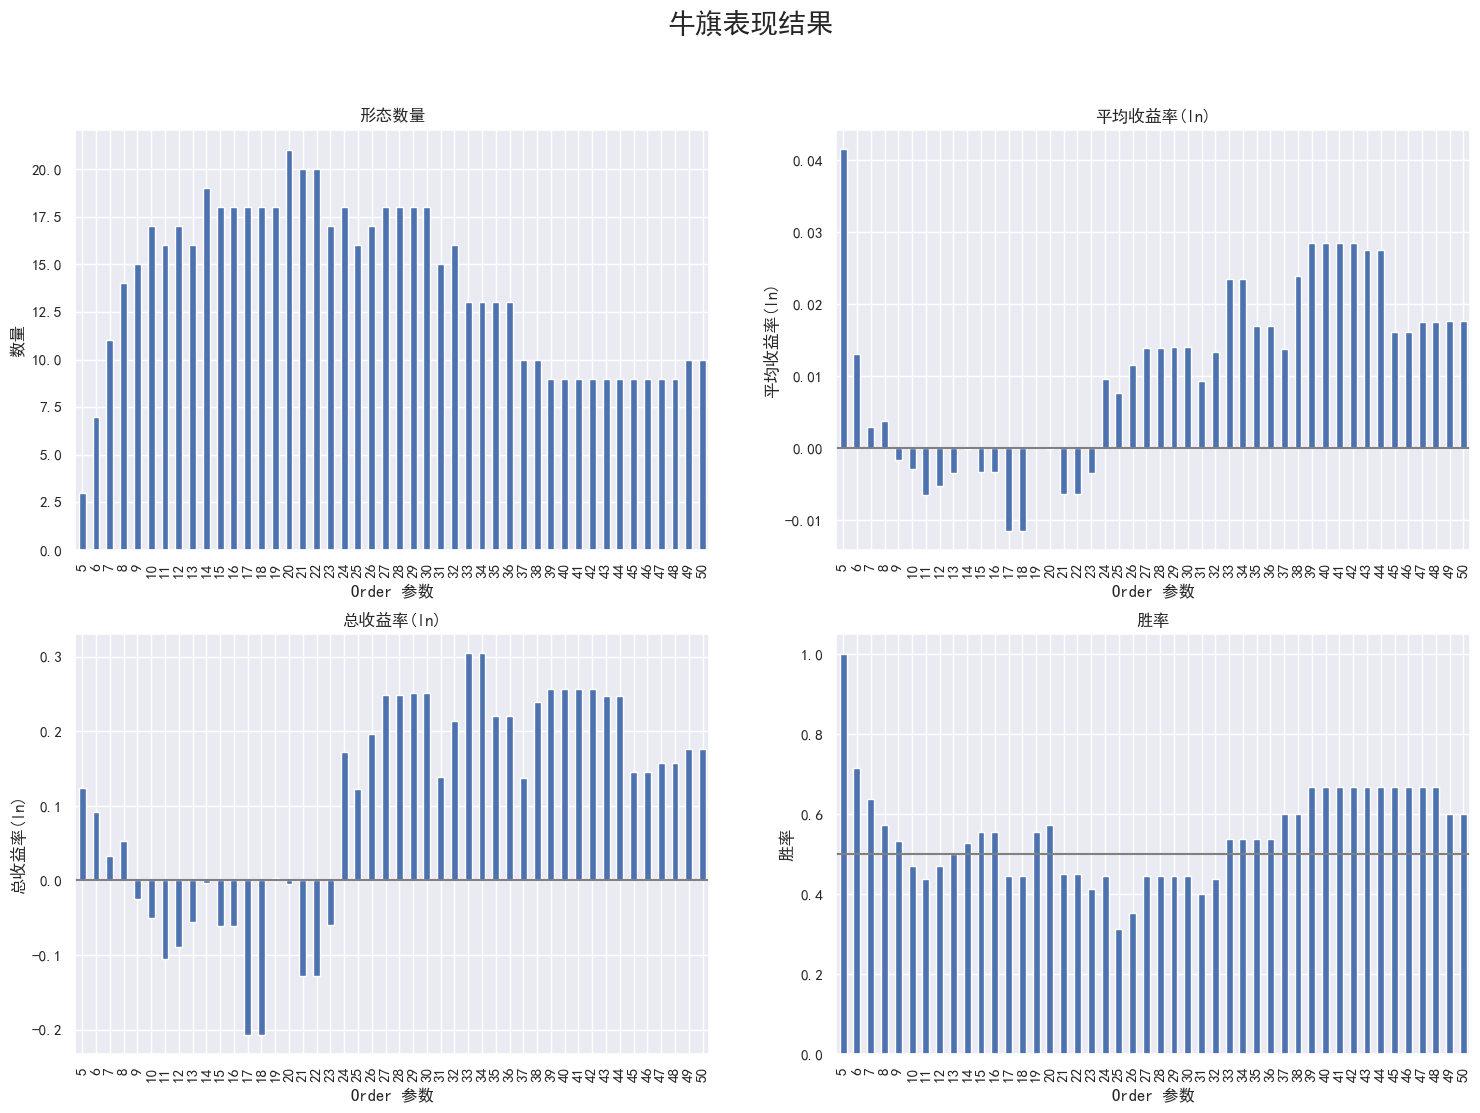

In [15]:

# 设置样式
sns.set_theme(style="darkgrid")
# sns.set_theme() 函数可以接受以下参数：
# context：控制绘图元素的比例，可选值有 "paper"、"notebook"、"talk"、"poster"，默认为 "notebook"
# style：控制绘图美学风格，可选值有 "darkgrid"、"whitegrid"、"dark"、"white"、"ticks"
# palette：控制颜色方案，可使用 Seaborn 内置调色板如 "deep"、"muted"、"bright" 等
# font：设置字体系列
# font_scale：字体大小的缩放因子
# color_codes：是否启用简短颜色代码
# rc：可传递字典覆盖默认的 matplotlib 参数

# sns.set_theme()与plt.style.use的区别：
# 1. sns.set_theme()是seaborn的新API，设置默认主题，包括颜色、网格等
# 2. plt.style.use直接使用Matplotlib的样式表，'seaborn-v0_8-bright'是保留的旧版seaborn风格
# sns.set_style("whitegrid")  # 设置网格样式

# 设置支持中文的字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决保存图像时负号'-'显示为方块的问题

# plt.style.use('seaborn-v0_8-bright')  # 使用seaborn亮色主题
fig, ax = plt.subplots(2, 2, figsize=(18, 12))  # 创建2x2的子图，设置图表大小为10x6

fig.suptitle("牛旗表现结果", fontsize=20)  # 设置总标题

# 绘制牛市旗形的四个指标
results_df['bull_flag_count'].plot.bar(ax=ax[0,0])  # 形态数量柱状图
results_df['bull_flag_avg'].plot.bar(ax=ax[0,1])  # 平均收益柱状图
results_df['bull_flag_total'].plot.bar(ax=ax[1,0])  # 总收益柱状图
results_df['bull_flag_wr'].plot.bar(ax=ax[1,1])  # 胜率柱状图

# 添加参考线
ax[0,1].hlines(0.0, xmin=-1, xmax=len(orders), color='gray')  # 平均收益为0的参考线
ax[1,0].hlines(0.0, xmin=-1, xmax=len(orders), color='gray')  # 总收益为0的参考线
ax[1,1].hlines(0.5, xmin=-1, xmax=len(orders), color='gray')  # 胜率为50%的参考线

# 设置子图标题和标签
ax[0,0].set_title('形态数量')  # 形态数量子图标题
ax[0,0].set_xlabel('Order 参数')  # x轴标签
ax[0,0].set_ylabel('数量')  # y轴标签
ax[0,1].set_title('平均收益率(ln)')  # 平均收益子图标题
ax[0,1].set_xlabel('Order 参数')  # x轴标签
ax[0,1].set_ylabel('平均收益率(ln)')  # y轴标签
ax[1,0].set_title('总收益率(ln)')  # 总收益子图标题
ax[1,0].set_xlabel('Order 参数')  # x轴标签
ax[1,0].set_ylabel('总收益率(ln)')  # y轴标签
ax[1,1].set_title('胜率')  # 胜率子图标题
ax[1,1].set_xlabel('Order 参数')  # x轴标签
ax[1,1].set_ylabel('胜率')  # y轴标签

plt.show()  # 显示图表

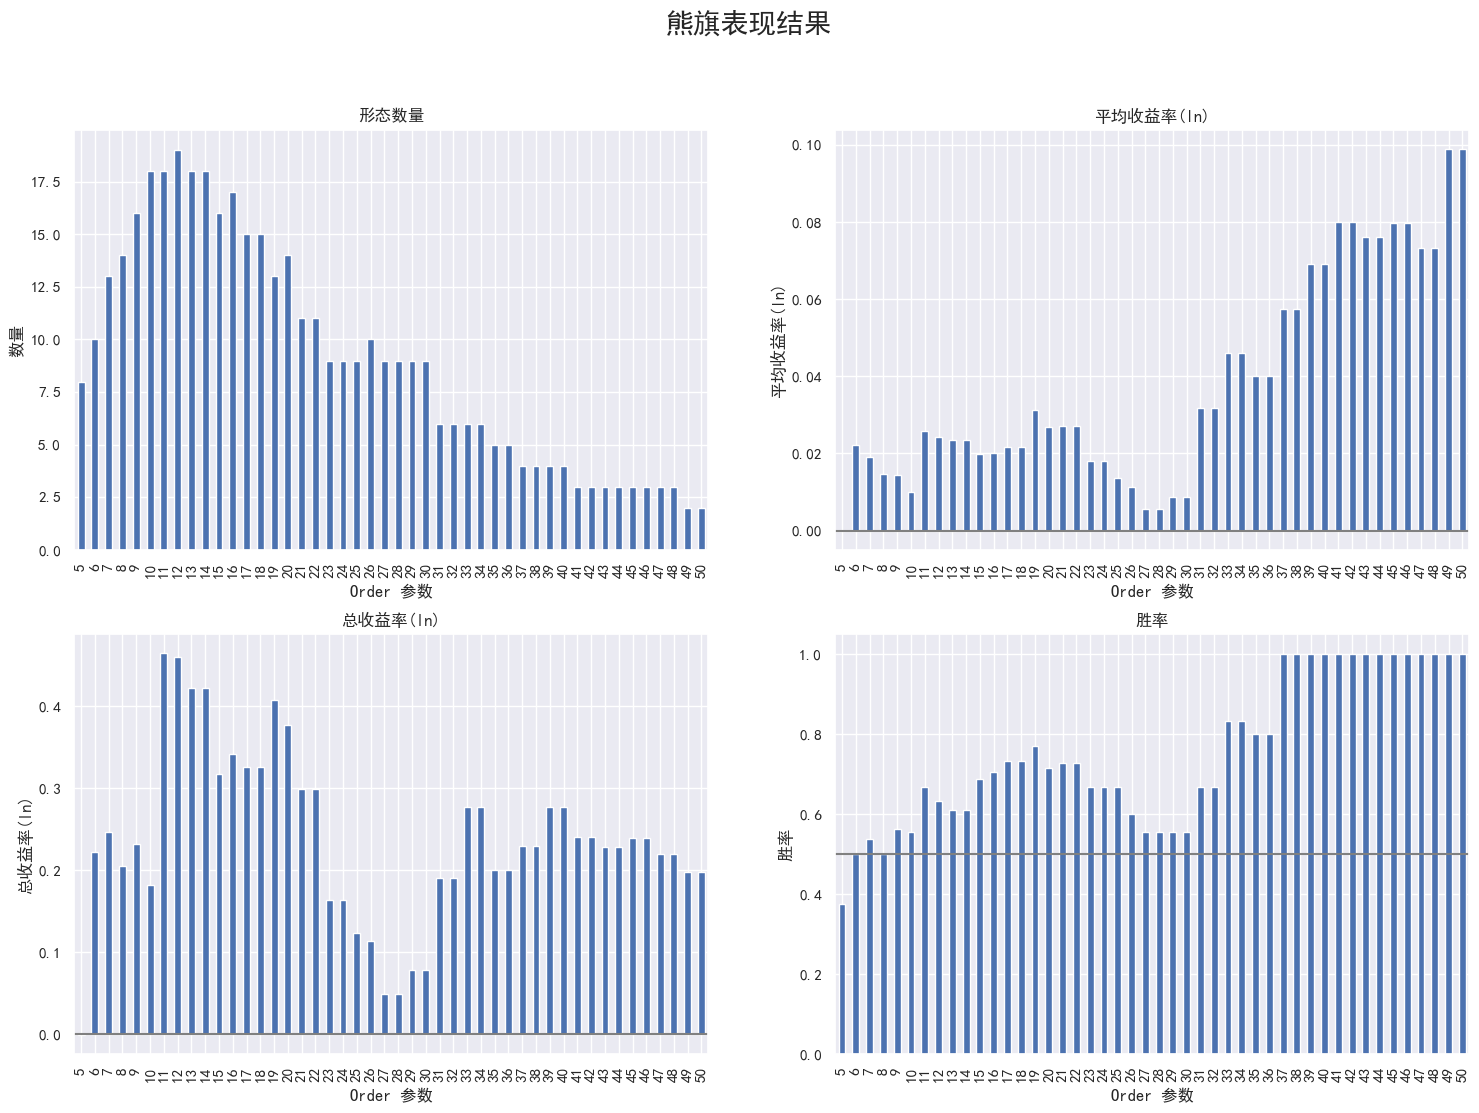

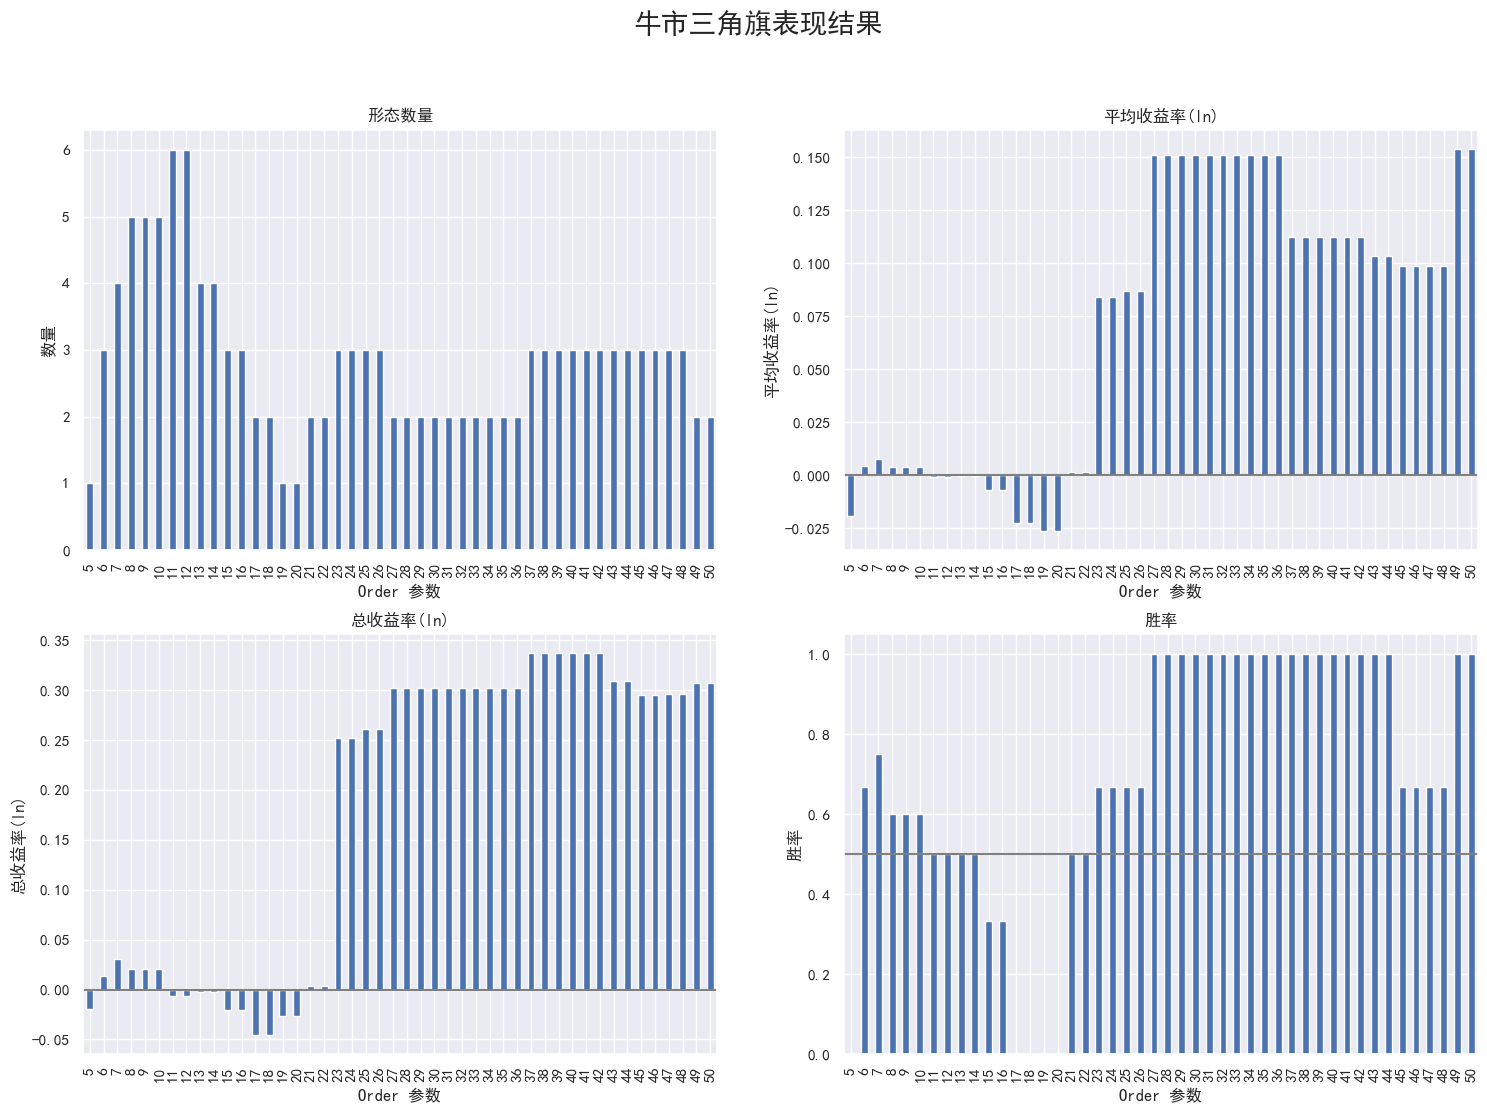

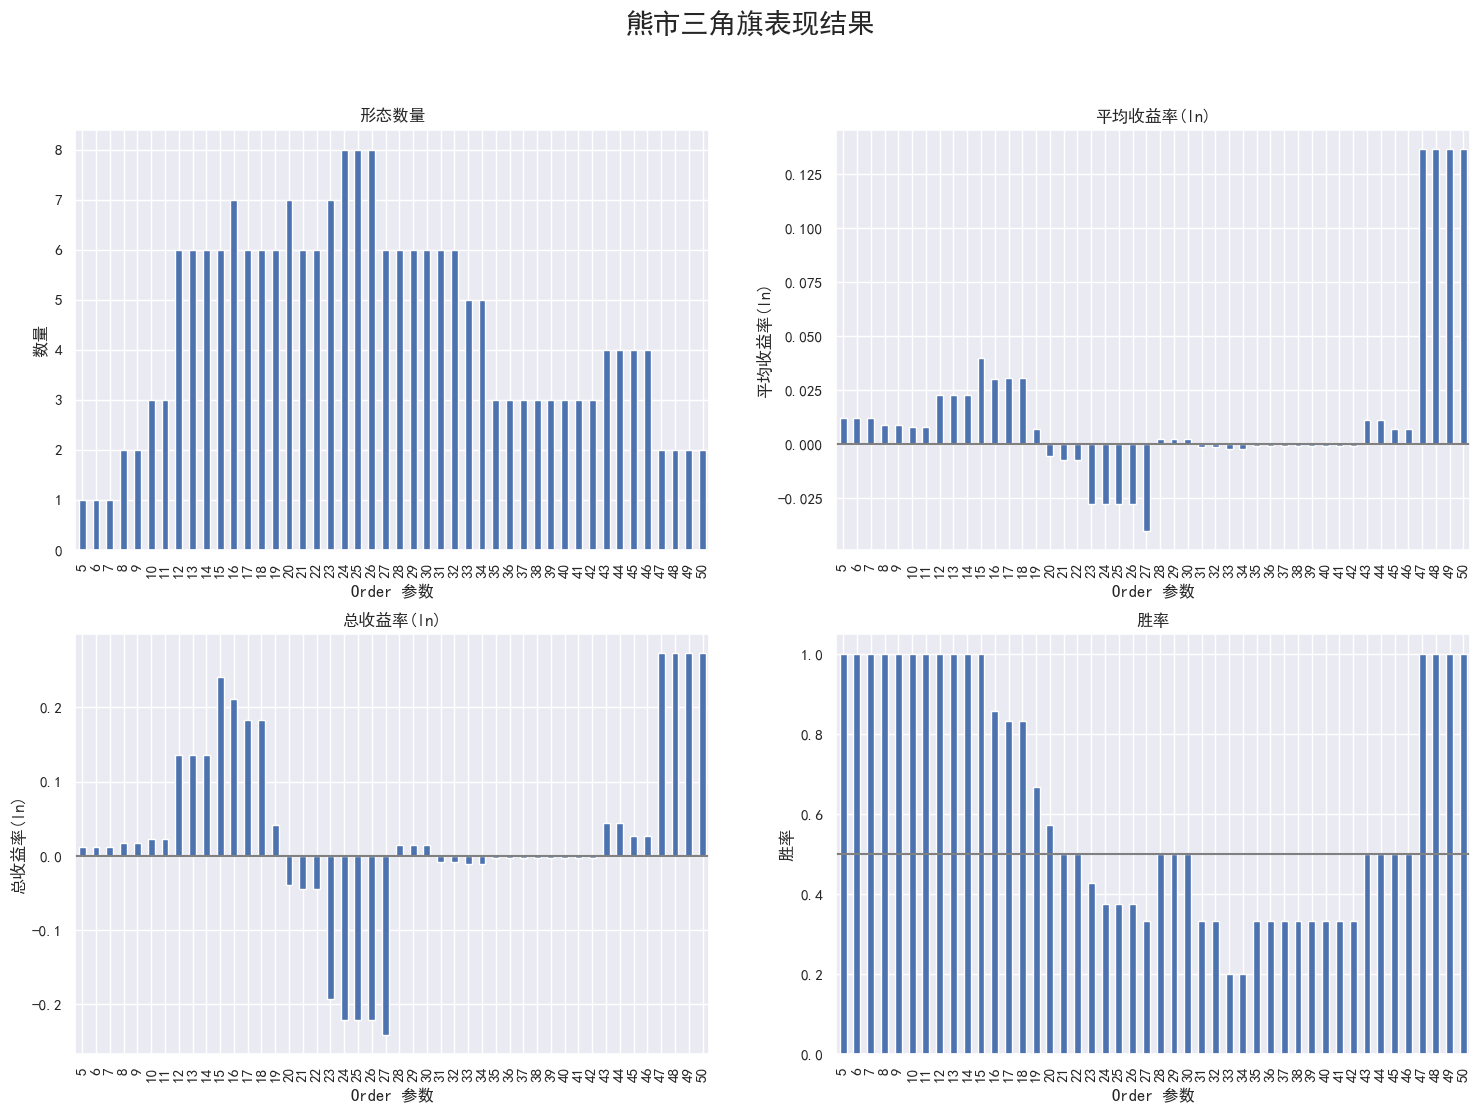

In [16]:
# 绘制熊市旗形的性能图表
fig, ax = plt.subplots(2, 2, figsize=(18, 12))  # 创建2x2的子图，设置图表大小为18x12
fig.suptitle("熊旗表现结果", fontsize=20)  # 设置总标题

# 绘制熊市旗形的四个指标
results_df['bear_flag_count'].plot.bar(ax=ax[0,0])  # 形态数量柱状图
results_df['bear_flag_avg'].plot.bar(ax=ax[0,1])  # 平均收益柱状图
results_df['bear_flag_total'].plot.bar(ax=ax[1,0])  # 总收益柱状图
results_df['bear_flag_wr'].plot.bar(ax=ax[1,1])  # 胜率柱状图

# 添加参考线
ax[0,1].hlines(0.0, xmin=-1, xmax=len(orders), color='gray')  # 平均收益为0的参考线
ax[1,0].hlines(0.0, xmin=-1, xmax=len(orders), color='gray')  # 总收益为0的参考线
ax[1,1].hlines(0.5, xmin=-1, xmax=len(orders), color='gray')  # 胜率为50%的参考线

# 设置子图标题和标签
ax[0,0].set_title('形态数量')  # 形态数量子图标题
ax[0,0].set_xlabel('Order 参数')  # x轴标签
ax[0,0].set_ylabel('数量')  # y轴标签
ax[0,1].set_title('平均收益率(ln)')  # 平均收益子图标题
ax[0,1].set_xlabel('Order 参数')  # x轴标签
ax[0,1].set_ylabel('平均收益率(ln)')  # y轴标签
ax[1,0].set_title('总收益率(ln)')  # 总收益子图标题
ax[1,0].set_xlabel('Order 参数')  # x轴标签
ax[1,0].set_ylabel('总收益率(ln)')  # y轴标签
ax[1,1].set_title('胜率')  # 胜率子图标题
ax[1,1].set_xlabel('Order 参数')  # x轴标签
ax[1,1].set_ylabel('胜率')  # y轴标签

plt.show()  # 显示图表


# 绘制牛市三角旗的性能图表
fig, ax = plt.subplots(2, 2, figsize=(18, 12))  # 创建2x2的子图，设置图表大小为18x12
fig.suptitle("牛市三角旗表现结果", fontsize=20)  # 设置总标题

# 绘制牛市三角旗的四个指标
results_df['bull_pennant_count'].plot.bar(ax=ax[0,0])  # 形态数量柱状图
results_df['bull_pennant_avg'].plot.bar(ax=ax[0,1])  # 平均收益柱状图
results_df['bull_pennant_total'].plot.bar(ax=ax[1,0])  # 总收益柱状图
results_df['bull_pennant_wr'].plot.bar(ax=ax[1,1])  # 胜率柱状图

# 添加参考线
ax[0,1].hlines(0.0, xmin=-1, xmax=len(orders), color='gray')  # 平均收益为0的参考线
ax[1,0].hlines(0.0, xmin=-1, xmax=len(orders), color='gray')  # 总收益为0的参考线
ax[1,1].hlines(0.5, xmin=-1, xmax=len(orders), color='gray')  # 胜率为50%的参考线

# 设置子图标题和标签
ax[0,0].set_title('形态数量')  # 形态数量子图标题
ax[0,0].set_xlabel('Order 参数')  # x轴标签
ax[0,0].set_ylabel('数量')  # y轴标签
ax[0,1].set_title('平均收益率(ln)')  # 平均收益子图标题
ax[0,1].set_xlabel('Order 参数')  # x轴标签
ax[0,1].set_ylabel('平均收益率(ln)')  # y轴标签
ax[1,0].set_title('总收益率(ln)')  # 总收益子图标题
ax[1,0].set_xlabel('Order 参数')  # x轴标签
ax[1,0].set_ylabel('总收益率(ln)')  # y轴标签
ax[1,1].set_title('胜率')  # 胜率子图标题
ax[1,1].set_xlabel('Order 参数')  # x轴标签
ax[1,1].set_ylabel('胜率')  # y轴标签

plt.show()  # 显示图表

# 绘制熊市三角旗的性能图表
fig, ax = plt.subplots(2, 2, figsize=(18, 12))  # 创建2x2的子图，设置图表大小为18x12
fig.suptitle("熊市三角旗表现结果", fontsize=20)  # 设置总标题

# 绘制熊市三角旗的四个指标
results_df['bear_pennant_count'].plot.bar(ax=ax[0,0])  # 形态数量柱状图
results_df['bear_pennant_avg'].plot.bar(ax=ax[0,1])  # 平均收益柱状图
results_df['bear_pennant_total'].plot.bar(ax=ax[1,0])  # 总收益柱状图
results_df['bear_pennant_wr'].plot.bar(ax=ax[1,1])  # 胜率柱状图

# 添加参考线
ax[0,1].hlines(0.0, xmin=-1, xmax=len(orders), color='gray')  # 平均收益为0的参考线
ax[1,0].hlines(0.0, xmin=-1, xmax=len(orders), color='gray')  # 总收益为0的参考线
ax[1,1].hlines(0.5, xmin=-1, xmax=len(orders), color='gray')  # 胜率为50%的参考线

# 设置子图标题和标签
ax[0,0].set_title('形态数量')  # 形态数量子图标题
ax[0,0].set_xlabel('Order 参数')  # x轴标签
ax[0,0].set_ylabel('数量')  # y轴标签
ax[0,1].set_title('平均收益率(ln)')  # 平均收益子图标题
ax[0,1].set_xlabel('Order 参数')  # x轴标签
ax[0,1].set_ylabel('平均收益率(ln)')  # y轴标签
ax[1,0].set_title('总收益率(ln)')  # 总收益子图标题
ax[1,0].set_xlabel('Order 参数')  # x轴标签
ax[1,0].set_ylabel('总收益率(ln)')  # y轴标签
ax[1,1].set_title('胜率')  # 胜率子图标题
ax[1,1].set_xlabel('Order 参数')  # x轴标签
ax[1,1].set_ylabel('胜率')  # y轴标签

plt.show()  # 显示图表

In [22]:
import plotly.graph_objects as go
# 将所有orders参数的旗形绘制在同一图中
def plot_all_orders_flags(data, orders_list):
    """
    绘制不同order参数下识别出的所有旗形到同一个图表中
    
    参数:
    data: pd.DataFrame - K线数据
    orders_list: list - order参数列表
    """
    # 创建图表对象
    fig = go.Figure()
    
    # 添加收盘价线图
    fig.add_trace(go.Scatter(
        x=data.index,
        y=data['Close'],
        mode='lines',
        name='收盘价',
        line=dict(color='black', width=1)
    ))
    
    # 为不同order参数定义不同颜色
    colors = plt.cm.rainbow(np.linspace(0, 1, len(orders_list)))
    
    # 遍历每个order参数
    for i, order in enumerate(orders_list):
        # 使用当前order参数识别旗形
        bull_flags, bear_flags, bull_pennants, bear_pennants = find_flags_pennants_pips(data['Close'].to_numpy(), order)
        
        # 合并所有类型的旗形
        all_patterns = bull_flags + bear_flags + bull_pennants + bear_pennants
        
        # 如果没有识别出旗形，继续下一个order
        if not all_patterns:
            continue
        
        # 为当前order参数的所有旗形添加标记
        for pattern in all_patterns:
            # 获取相对于显示范围的索引
            base_idx = data.index[pattern.base_x]
            tip_idx = data.index[pattern.tip_x]
            conf_idx = data.index[pattern.conf_x]
            
            # 添加旗杆线
            fig.add_trace(go.Scatter(
                x=[base_idx, tip_idx],
                y=[pattern.base_y, pattern.tip_y],
                mode='lines',
                line=dict(color=f'rgba({int(colors[i][0]*255)},{int(colors[i][1]*255)},{int(colors[i][2]*255)},1)', width=1),
                name=f'Order={order}',
                showlegend=False
            ))
            
            # 添加趋势线
            resist_y = [pattern.resist_intercept, 
                       pattern.resist_intercept + pattern.resist_slope * pattern.flag_width]
            support_y = [pattern.support_intercept,
                        pattern.support_intercept + pattern.support_slope * pattern.flag_width]
            
            fig.add_trace(go.Scatter(
                x=[tip_idx, conf_idx],
                y=[resist_y[0], resist_y[1]],
                mode='lines',
                line=dict(color=f'rgba({int(colors[i][0]*255)},{int(colors[i][1]*255)},{int(colors[i][2]*255)},1)', dash='dash'),
                showlegend=False
            ))
            
            fig.add_trace(go.Scatter(
                x=[tip_idx, conf_idx],
                y=[support_y[0], support_y[1]],
                mode='lines',
                line=dict(color=f'rgba({int(colors[i][0]*255)},{int(colors[i][1]*255)},{int(colors[i][2]*255)},1)', dash='dash'),
                showlegend=False
            ))
            
            # 添加关键点
            fig.add_trace(go.Scatter(
                x=[base_idx, tip_idx, conf_idx],
                y=[pattern.base_y, pattern.tip_y, pattern.conf_y],
                mode='markers',
                marker=dict(size=6, color=f'rgba({int(colors[i][0]*255)},{int(colors[i][1]*255)},{int(colors[i][2]*255)},1)'),
                name=f'Order={order}',
                showlegend=(pattern == all_patterns[0])  # 只为每个order显示一次图例
            ))
    
    # 更新图表布局
    fig.update_layout(
        template='plotly',
        xaxis_title='日期',
        yaxis_title='价格(对数)',
        showlegend=True,
        height=800,
        title='不同Order参数下的旗形识别结果对比'
    )
    
    # 添加范围滑块
    fig.update_xaxes(rangeslider_visible=True)
    
    return fig

# 使用函数绘制所有orders参数的旗形
orders = list(range(5, 51))
fig_all_orders = plot_all_orders_flags(data, orders)

# 使用plotly的显示方法而不是plt.show()
# fig_all_orders.show()

# 保存为HTML文件
fig_all_orders.write_html("不同Order参数下的旗形识别结果对比.html")

# 保存为图片格式
fig_all_orders.write_image("不同Order参数下的旗形识别结果对比.png", width=1600, height=900)

print("已生成不同Order参数下的旗形识别结果对比.html和不同Order参数下的旗形识别结果对比.png")


已生成不同Order参数下的旗形识别结果对比.html和不同Order参数下的旗形识别结果对比.png
